In [1]:
import pandas as pd 
import numpy as np 
import zipfile 
import io 
import requests 
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import StandardScaler 
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score 
from tensorflow import keras 
from tensorflow.keras import layers 

In [2]:
url = "https://archive.ics.uci.edu/static/public/275/bike+sharing+dataset.zip" 
r = requests.get(url) 
z = zipfile.ZipFile(io.BytesIO(r.content)) 
day_data = pd.read_csv(z.open("day.csv")) 

In [3]:
day_data = day_data.drop(columns=["instant", "dteday", "casual", "registered"]) 

X = day_data.drop("cnt", axis=1)
y = day_data["cnt"]

In [5]:
scaler = StandardScaler() 
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42) 

In [6]:
model = keras.Sequential([ 
layers.Dense(128, activation='relu', input_shape=(X_train.shape[1],)), 
layers.Dense(64, activation='relu'), 
layers.Dense(1)
]) 

In [7]:
model.compile(optimizer='adam', loss='mse', metrics=['mae']) 

In [8]:
early_stop = keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True) 

In [9]:
history = model.fit( 
            X_train, y_train, 
            epochs=100, 
            batch_size=32, 
            validation_split=0.2, 
            callbacks=[early_stop], 
            verbose=1 
        ) 

Epoch 1/100
15/15 [==============================] - 1s 11ms/step - loss: 24950900.0000 - mae: 4617.0347 - val_loss: 22501850.0000 - val_mae: 4332.4907
Epoch 2/100
15/15 [==============================] - 0s 2ms/step - loss: 24932768.0000 - mae: 4614.9722 - val_loss: 22480586.0000 - val_mae: 4329.9873
Epoch 3/100
15/15 [==============================] - 0s 3ms/step - loss: 24904172.0000 - mae: 4611.8911 - val_loss: 22445732.0000 - val_mae: 4326.0098
Epoch 4/100
15/15 [==============================] - 0s 2ms/step - loss: 24857094.0000 - mae: 4606.8643 - val_loss: 22388574.0000 - val_mae: 4319.7334
Epoch 5/100
15/15 [==============================] - 0s 2ms/step - loss: 24778840.0000 - mae: 4598.8906 - val_loss: 22299848.0000 - val_mae: 4310.2295
Epoch 6/100
15/15 [==============================] - 0s 2ms/step - loss: 24659990.0000 - mae: 4586.9404 - val_loss: 22166140.0000 - val_mae: 4296.3433
Epoch 7/100
15/15 [==============================] - 0s 2ms/step - loss: 24483512.0000 - mae:

15/15 [==============================] - 0s 2ms/step - loss: 1496691.2500 - mae: 955.7491 - val_loss: 1582920.2500 - val_mae: 991.5667
Epoch 56/100
15/15 [==============================] - 0s 2ms/step - loss: 1478178.1250 - mae: 949.0753 - val_loss: 1558549.7500 - val_mae: 986.3504
Epoch 57/100
15/15 [==============================] - 0s 2ms/step - loss: 1456715.3750 - mae: 942.0086 - val_loss: 1538051.3750 - val_mae: 982.0495
Epoch 58/100
15/15 [==============================] - 0s 3ms/step - loss: 1439213.8750 - mae: 934.5495 - val_loss: 1515459.2500 - val_mae: 977.1934
Epoch 59/100
15/15 [==============================] - 0s 2ms/step - loss: 1424112.3750 - mae: 928.6082 - val_loss: 1493896.2500 - val_mae: 973.8574
Epoch 60/100
15/15 [==============================] - 0s 2ms/step - loss: 1405516.7500 - mae: 922.2445 - val_loss: 1477108.6250 - val_mae: 968.6296
Epoch 61/100
15/15 [==============================] - 0s 2ms/step - loss: 1388269.1250 - mae: 916.3856 - val_loss: 1457922.25

In [10]:
loss, mae = model.evaluate(X_test, y_test) 
print(f"\nTest MAE: {mae:.2f}") 

5/5 [==============================] - 0s 1ms/step - loss: 1060397.7500 - mae: 760.5618

Test MAE: 760.56


In [11]:
y_pred = model.predict(X_test).flatten() 

5/5 [==============================] - 0s 1ms/step


Test MSE: 1060397.77
R² Score: 0.74


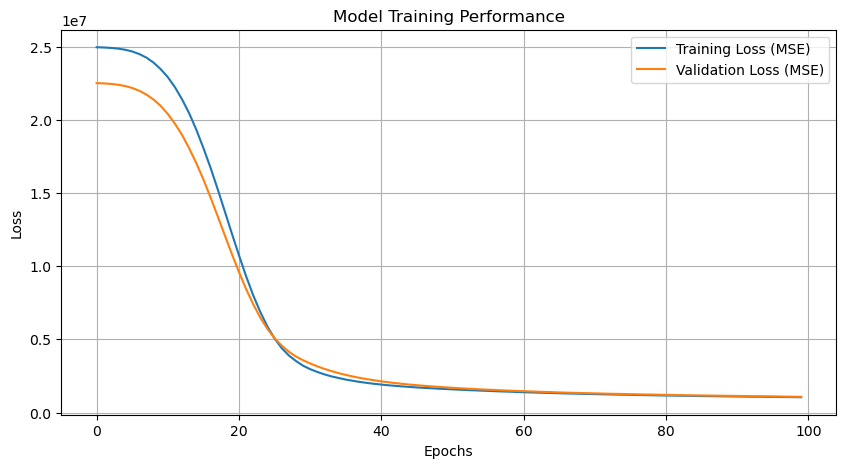

In [12]:
mse = mean_squared_error(y_test, y_pred) 
r2 = r2_score(y_test, y_pred) 
print(f"Test MSE: {mse:.2f}") 
print(f"R² Score: {r2:.2f}") 
plt.figure(figsize=(10, 5)) 
plt.plot(history.history['loss'], label='Training Loss (MSE)') 
plt.plot(history.history['val_loss'], label='Validation Loss (MSE)') 
plt.title('Model Training Performance') 
plt.xlabel('Epochs') 
plt.ylabel('Loss') 
plt.legend() 
plt.grid(True) 
plt.show() 